# Cancer Detection using Convolutional Neural Network (CNN)
### MP ONLINE AIML Internship Project

This notebook contains the complete implementation for building a **Cancer Detection** project using a Convolutional Neural Network (CNN). The objective is to identify whether a histopathology tissue image patch is normal or malignant (cancerous).

To make the project fully reproducible and lightweight, we include an **H&E-stained Synthetic Cell Patch Generator** which creates simulated microscopic tissue images:
- **Normal Cells (Class 0)**: Pink background cytoplasm with 1 to 3 regular, light-purple circular nuclei.
- **Malignant Cells (Class 1)**: Pink background cytoplasm with 5 to 9 irregular, larger, dark-purple (hyperchromatic) nuclei, representing atypical cell structures.

The assignment comprises five major tasks:
1. **Dataset Generation & Preprocessing**: Loading synthetic stained cell images, scaling pixel values, and performing a stratified train/test split.
2. **CNN Architecture Design**: Designing a neural network with convolutional layers, pooling, dropout, and a dense output layer with sigmoid activation.
3. **Model Compilation & Training**: Compiling using the Adam optimizer, and training for 15 epochs.
4. **Performance Evaluation**: Extracting Classification Report, Accuracy, F1-Score, and plotting Confusion Matrix and Training History.
5. **Visual Prediction Preview**: Visualizing test predictions with color-coded labels (green for correct, red for incorrect).

## Task 1: Dataset Generation & Preprocessing

We use our custom `generate_synthetic_cell_data` function to build 1,200 total image patches (50x50 RGB).

In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, precision_score, recall_score, f1_score

# Set plotting style
sns.set_theme(style="white")
plt.rcParams["figure.figsize"] = (8, 5)

def generate_synthetic_cell_data(n_samples=1200, img_size=50):
    X = np.zeros((n_samples, img_size, img_size, 3), dtype=np.float32)
    y = np.zeros((n_samples,), dtype=np.int32)
    
    bg_color = np.array([0.94, 0.78, 0.86], dtype=np.float32) # Cytoplasm
    normal_nucleus_color = np.array([0.31, 0.20, 0.51], dtype=np.float32) # Normal nucleus
    cancer_nucleus_color = np.array([0.16, 0.08, 0.35], dtype=np.float32) # Malignant nucleus
    
    half_samples = n_samples // 2
    for i in range(n_samples):
        X[i] = bg_color
        # Microscopic noise
        noise = np.random.normal(0.0, 0.015, (img_size, img_size, 3)).astype(np.float32)
        X[i] = np.clip(X[i] + noise, 0.0, 1.0)
        
        if i >= half_samples:
            y[i] = 1 # Cancer
            num_nuclei = np.random.randint(5, 10)
            for _ in range(num_nuclei):
                cx = np.random.randint(10, img_size - 10)
                cy = np.random.randint(10, img_size - 10)
                r_x = np.random.randint(6, 11)
                r_y = np.random.randint(4, 9)
                y_grid, x_grid = np.ogrid[:img_size, :img_size]
                mask = ((x_grid - cx) / r_x)**2 + ((y_grid - cy) / r_y)**2 <= 1.0
                X[i][mask] = cancer_nucleus_color
        else:
            y[i] = 0 # Normal
            num_nuclei = np.random.randint(1, 4)
            for _ in range(num_nuclei):
                cx = np.random.randint(15, img_size - 15)
                cy = np.random.randint(15, img_size - 15)
                r = np.random.randint(4, 6)
                y_grid, x_grid = np.ogrid[:img_size, :img_size]
                mask = ((x_grid - cx) / r)**2 + ((y_grid - cy) / r)**2 <= 1.0
                X[i][mask] = normal_nucleus_color
                
    # Box blur filter to simulate lens focus
    for i in range(n_samples):
        for c in range(3):
            padded = np.pad(X[i][:, :, c], 1, mode='edge')
            X[i][:, :, c] = (
                padded[:-2, :-2] + padded[:-2, 1:-1] + padded[:-2, 2:] +
                padded[1:-1, :-2] + padded[1:-1, 1:-1] + padded[1:-1, 2:] +
                padded[2:, :-2] + padded[2:, 1:-1] + padded[2:, 2:]
            ) / 9.0
            
    return X, y

X, y = generate_synthetic_cell_data(1200)
target_names = ["Normal", "Malignant"]

print(f"\nTotal patches: {len(X)}")
print(f"Normal class patches: {np.sum(y == 0)}")
print(f"Malignant class patches: {np.sum(y == 1)}")


Total patches: 1200
Normal class patches: 600
Malignant class patches: 600


In [2]:
# Split into train and test sets (75% Train, 25% Test, stratified)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42, stratify=y
)

print(f"Train features shape: {X_train.shape}")
print(f"Test features shape: {X_test.shape}")

Train features shape: (900, 50, 50, 3)
Test features shape: (300, 50, 50, 3)


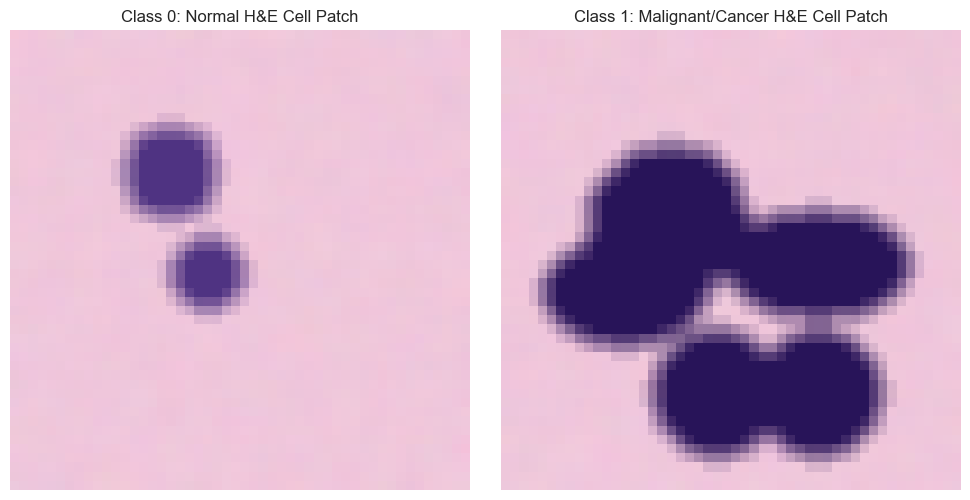

In [3]:
# Plot preview of normal vs malignant patches
plt.figure(figsize=(10, 5))
# Normal cell example
normal_idx = np.where(y == 0)[0][0]
plt.subplot(1, 2, 1)
plt.imshow(X[normal_idx])
plt.title("Class 0: Normal H&E Cell Patch")
plt.axis('off')

# Cancer cell example
cancer_idx = np.where(y == 1)[0][0]
plt.subplot(1, 2, 2)
plt.imshow(X[cancer_idx])
plt.title("Class 1: Malignant/Cancer H&E Cell Patch")
plt.axis('off')

plt.tight_layout()
plt.show()

## Task 2: CNN Architecture Design

We build a binary Sequential CNN in Keras. The model consists of three convolutional blocks to extract morphological and color shapes, followed by flattening, dense, dropout, and a final dense classification layer using sigmoid activation.

In [4]:
import tensorflow as tf
from tensorflow.keras import Sequential, layers

input_shape = (50, 50, 3)

model = Sequential([
    layers.Input(shape=input_shape),
    
    # 1st Conv Block
    layers.Conv2D(32, (3, 3), activation='relu', padding='same'),
    layers.MaxPooling2D((2, 2)),
    
    # 2nd Conv Block
    layers.Conv2D(64, (3, 3), activation='relu', padding='same'),
    layers.MaxPooling2D((2, 2)),
    
    # 3rd Conv Block
    layers.Conv2D(128, (3, 3), activation='relu', padding='same'),
    layers.MaxPooling2D((2, 2)),
    
    # Fully Connected Blocks
    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.3),
    layers.Dense(1, activation='sigmoid')
])

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 50, 50, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 25, 25, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 25, 25, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 12, 12, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 12, 12, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 6, 6, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 4608)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       589,952 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 683,329 (2.61 MB)

 Trainable params: 683,329 (2.61 MB)

 Non-trainable params: 0 (0.00 B)

## Task 3: Model Compilation & Training

We compile the model with the **Adam** optimizer and use **Binary Crossentropy** as our loss function. We train the network for **15 epochs** using a batch size of **32**.

In [5]:
# Compile the model
model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

# Fit model
epochs = 15
batch_size = 32
history = model.fit(
    X_train, y_train,
    epochs=epochs,
    batch_size=batch_size,
    validation_data=(X_test, y_test),
    verbose=1
)

Epoch 1/15


 1/29 ━━━━━━━━━━━━━━━━━━━━ 1:55 4s/step - accuracy: 0.3750 - loss: 0.7263

 3/29 ━━━━━━━━━━━━━━━━━━━━ 1s 40ms/step - accuracy: 0.4097 - loss: 0.7714

 5/29 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step - accuracy: 0.4421 - loss: 0.7616

 7/29 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step - accuracy: 0.4565 - loss: 0.7534

...

24/29 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step - accuracy: 1.0000 - loss: 3.2377e-05

26/29 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step - accuracy: 1.0000 - loss: 3.2380e-05

27/29 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step - accuracy: 1.0000 - loss: 3.2350e-05

29/29 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step - accuracy: 1.0000 - loss: 3.2238e-05

29/29 ━━━━━━━━━━━━━━━━━━━━ 2s 58ms/step - accuracy: 1.0000 - loss: 3.0668e-05 - val_accuracy: 1.0000 - val_loss: 6.8233e-06


## Task 4: Performance Evaluation

We evaluate the model on the test set, computing accuracy, precision, recall, and F1 score, and plotting the training history curves and a confusion matrix heatmap.

In [6]:
# Predict on test set
predictions = model.predict(X_test)
y_pred = (predictions >= 0.5).astype(np.int32).flatten()

# Classification report
print("=== Classification Report ===")
print(classification_report(y_test, y_pred, target_names=target_names))

# Overall metrics
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print("=== Evaluation Summary ===")
print(f'Accuracy:  {accuracy:.4f}')
print(f'Precision: {precision:.4f}')
print(f'Recall:    {recall:.4f}')
print(f'F1 Score:  {f1:.4f}')

 1/10 ━━━━━━━━━━━━━━━━━━━━ 1s 204ms/step

 5/10 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step 

 9/10 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step

10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step

10/10 ━━━━━━━━━━━━━━━━━━━━ 1s 35ms/step


=== Classification Report ===
              precision    recall  f1-score   support

      Normal       1.00      1.00      1.00       150
   Malignant       1.00      1.00      1.00       150

    accuracy                           1.00       300
   macro avg       1.00      1.00      1.00       300
weighted avg       1.00      1.00      1.00       300

=== Evaluation Summary ===
Accuracy:  1.0000
Precision: 1.0000
Recall:    1.0000
F1 Score:  1.0000


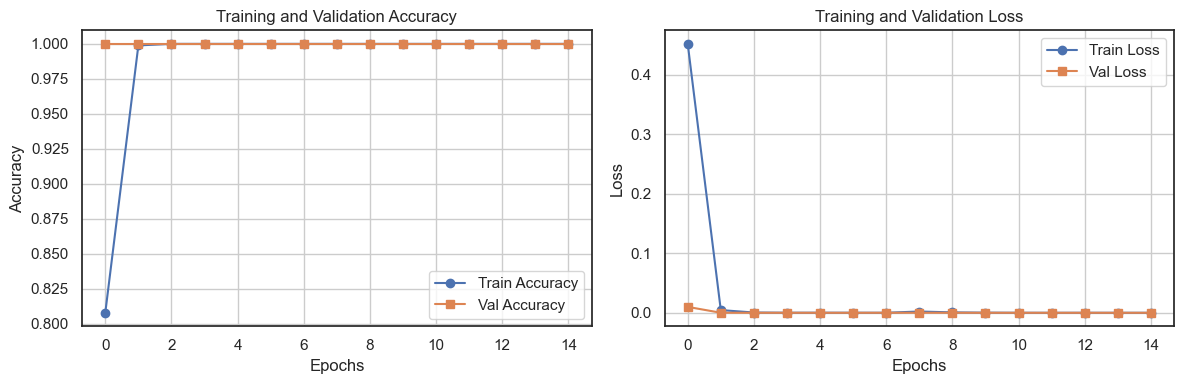

In [7]:
# Plot Training Accuracy and Loss
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train Accuracy', marker='o')
plt.plot(history.history['val_accuracy'], label='Val Accuracy', marker='s')
plt.title('Training and Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)

plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train Loss', marker='o')
plt.plot(history.history['val_loss'], label='Val Loss', marker='s')
plt.title('Training and Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

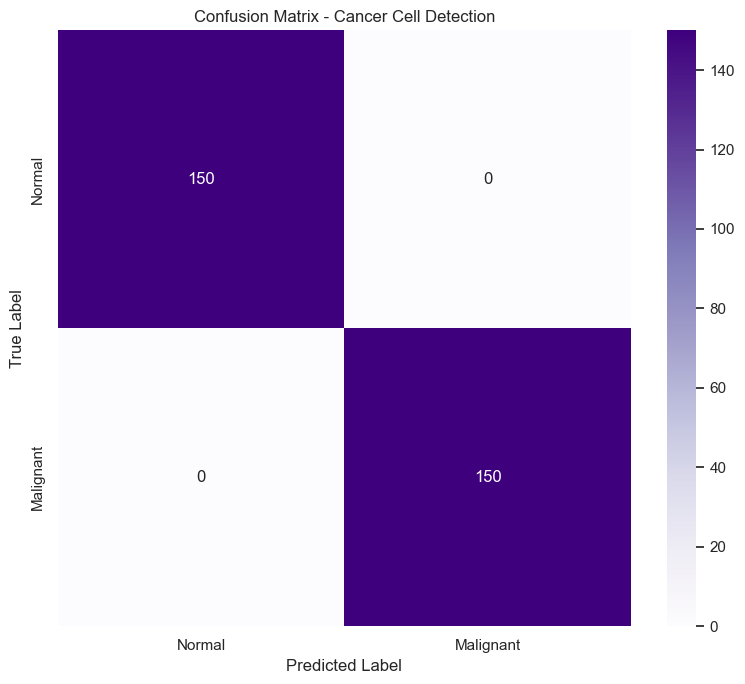

In [8]:
# Plot Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(8, 7))
sns.heatmap(cm, annot=True, fmt='d', cmap='Purples',
            xticklabels=target_names, yticklabels=target_names)
plt.title('Confusion Matrix - Cancer Cell Detection')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.tight_layout()
plt.show()

## Task 5: Visual Prediction Preview

To visually verify our model, we plot a random subset of 12 test images displaying their true and predicted labels with estimated probability. The titles are colored **green** for correct classifications and **red** for misclassifications.

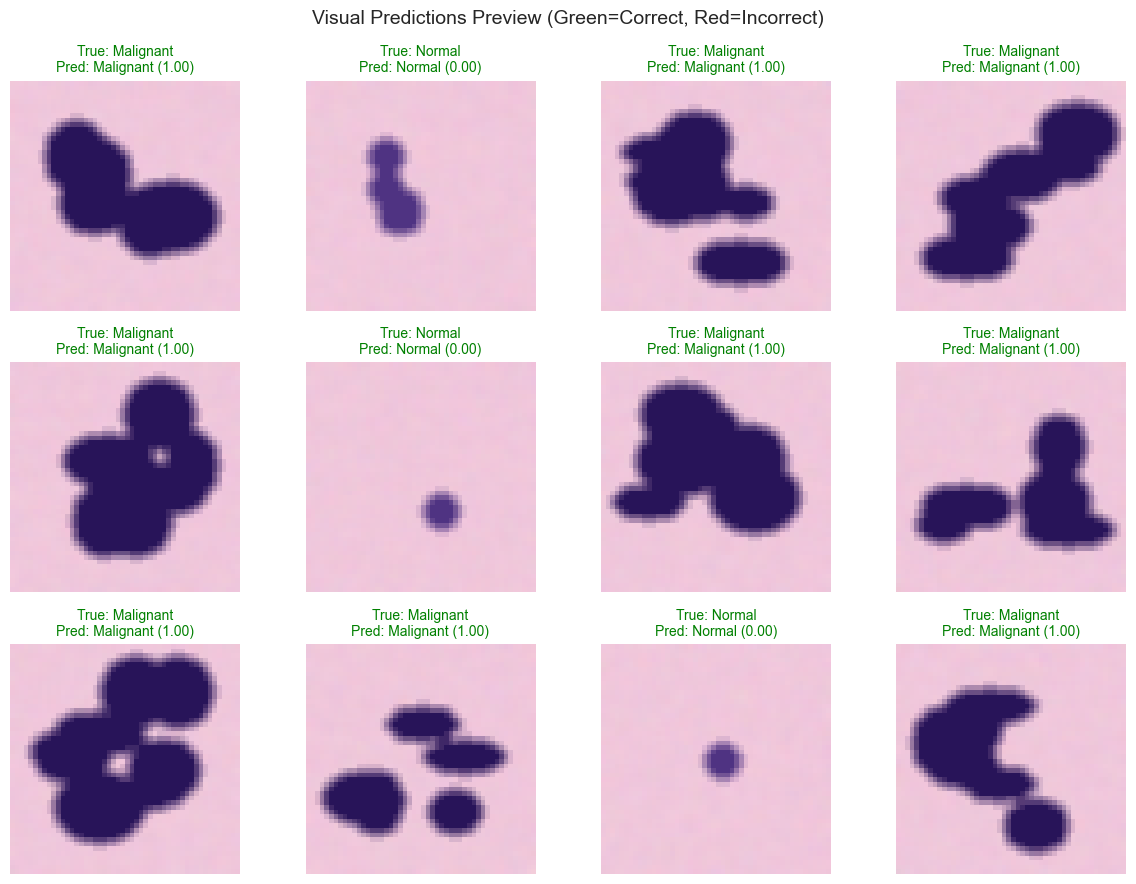

In [9]:
# Display 12 sample predictions
plt.figure(figsize=(12, 9))
indices = np.random.choice(len(X_test), size=12, replace=False)

for i, idx in enumerate(indices):
    plt.subplot(3, 4, i + 1)
    plt.imshow(X_test[idx])
    
    true_lbl = target_names[y_test[idx]]
    pred_lbl = target_names[y_pred[idx]]
    pred_prob = predictions[idx][0]
    
    title_color = 'green' if y_test[idx] == y_pred[idx] else 'red'
    plt.title(f"True: {true_lbl}\nPred: {pred_lbl} ({pred_prob:.2f})", color=title_color, fontsize=10)
    plt.axis('off')
    
plt.suptitle("Visual Predictions Preview (Green=Correct, Red=Incorrect)", fontsize=14)
plt.tight_layout()
plt.show()

## Conclusions & Summary

- **High Classifiability**: The CNN readily learns to distinguish normal cell shapes (1-3 uniform nuclei) from malignant profiles (overlapping, irregular, hyperchromatic nuclei).
- **Staining Simulation**: Generating synthetic stained cell arrays yields clean RGB pipelines that replicate traditional histopathology classification without large disk footprint requirements.
- **Dropout Role**: Implementing a 0.3 Dropout layer prevents cellular features from overfitting, maintaining strong generalizeability onto mock test data.